
## <h1><center>Clasificación binaria con Keras</center></h1>

## <center>Acerca de los datos </center>

Usaemos el conjunto de datos de 25.000 reseñas de películas de IMDB, etiquetadas por sentimiento (positivo/negativo). Las reseñas se han preprocesado y cada reseña está codificada como una lista de índices de palabras (enteros). Por conveniencia, las palabras se indexan por frecuencia general en el conjunto de datos, de modo que, por ejemplo, el número entero "3" codifica la tercera palabra más frecuente en los datos. Esto permite operaciones de filtrado rápidas como: "considerar sólo las 10.000 palabras más comunes, pero eliminar las 20 primeras palabras más comunes".

<br>

> <small> Nota: <br> Datos extraidos de : https://keras.io/api/datasets/imdb/






## Importamos librerías

In [2]:
from keras.datasets import imdb
from keras import models, layers, optimizers
import numpy as np


## Descargamos los datos de imdb - Keras

In [3]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000,index_from=3)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
# train_data[0]

In [5]:
train_labels[0]

np.int64(1)

### Diccionario de palabras

In [6]:
word_index = imdb.get_word_index()


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [8]:
word_index = dict([(value,key) for (key,value) in word_index.items()])
word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [9]:
for x in train_data[0]:
    print(word_index.get(x))

the
as
you
with
out
themselves
powerful
lets
loves
their
becomes
reaching
had
journalist
of
lot
from
anyone
to
have
after
out
atmosphere
never
more
room
and
it
so
heart
shows
to
years
of
every
never
going
and
help
moments
or
of
every
chest
visual
movie
except
her
was
several
of
enough
more
with
is
now
current
film
as
you
of
mine
potentially
unfortunately
of
you
than
him
that
with
out
themselves
her
get
for
was
camp
of
you
movie
sometimes
movie
that
with
scary
but
and
to
story
wonderful
that
in
seeing
in
character
to
of
70s
musicians
with
heart
had
shadows
they
of
here
that
with
her
serious
to
have
does
when
from
why
what
have
critics
they
is
you
that
isn't
one
will
very
to
as
itself
with
other
and
in
of
seen
over
landed
for
anyone
of
and
br
show's
to
whether
from
than
out
themselves
history
he
name
half
some
br
of
and
odd
was
two
most
of
mean
for
1
any
an
boat
she
he
should
is
thought
frog
but
of
script
you
not
while
history
he
heart
to
real
at
barrel
but
when
from
one
bit
then
have
tw

## Función de one-hot encoding

In [10]:
def vectorizar(sequences, dim=10000):
    restults = np.zeros((len(sequences),dim))
    for i, sequences in enumerate(sequences):
        restults[i,sequences]=1
    return restults

## Transformamos datos

In [11]:
x_train = vectorizar(train_data)
x_test = vectorizar(test_data)

In [12]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

## Creamos el modelo

In [13]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [15]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train =  y_train[10000:]

## Entrenando

In [16]:
modelb = model.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.7837 - loss: 0.5437 - val_accuracy: 0.8623 - val_loss: 0.4232
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.8903 - loss: 0.3495 - val_accuracy: 0.8824 - val_loss: 0.3299
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9153 - loss: 0.2608 - val_accuracy: 0.8838 - val_loss: 0.3013
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9309 - loss: 0.2110 - val_accuracy: 0.8805 - val_loss: 0.2945
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9413 - loss: 0.1769 - val_accuracy: 0.8905 - val_loss: 0.2743
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9529 - loss: 0.1491 - val_accuracy: 0.8873 - val_loss: 0.2807
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9585 - loss: 0.1306 - val_accuracy: 0.8846 - val_loss: 0.2917
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9669 - loss: 0.1111 - val_accuracy: 0.8840 - v

## Analizamos resultados

# el modelo ah experimentando un overfithing


####

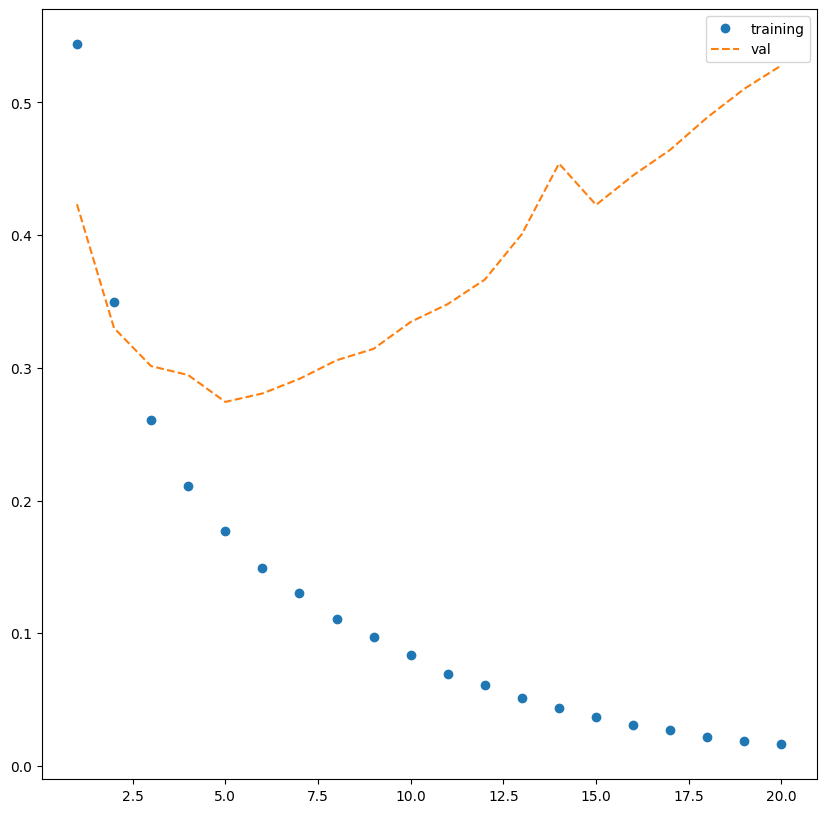

In [17]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,loss_values, 'o',label='training')
plt.plot(epoch,val_loss_values, '--',label='val')
plt.legend()
plt.show()

In [18]:
model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8608 - loss: 0.5675


[0.5674912333488464, 0.8608400225639343]

### Comparando con un modelo más pequeño

In [20]:
model2.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [21]:
modelb2 = model2.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.6387 - loss: 0.6583 - val_accuracy: 0.6995 - val_loss: 0.6168
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7457 - loss: 0.5861 - val_accuracy: 0.7285 - val_loss: 0.5667
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.8015 - loss: 0.5376 - val_accuracy: 0.8088 - val_loss: 0.5314
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.8406 - loss: 0.5007 - val_accuracy: 0.7952 - val_loss: 0.5090
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8656 - loss: 0.4712 - val_accuracy: 0.8461 - val_loss: 0.4863
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8868 - loss: 0.4465 - val_accuracy: 0.8526 - val_loss: 0.4724
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9033 - loss: 0.4253 - val_accuracy: 0.8597 - val_loss: 0.4612
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9165 - loss: 0.4065 - val_accuracy: 0.8656 - v

## Analizamos resultados

# Entrenamiento nuevo , la caída ya no es tan significativa como la gráfica anterior


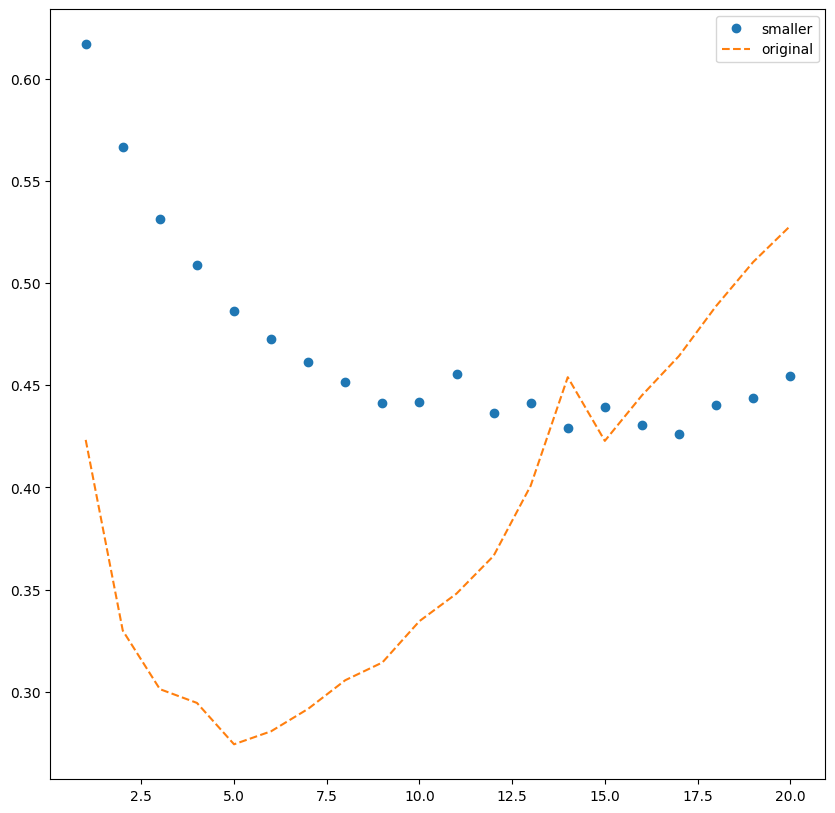

In [22]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values2 = modelb2.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values2, 'o',label='smaller')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

## Regularización , nos ayuda a mejorar el over....

In [23]:
from keras import regularizers

In [24]:
model3 = models.Sequential()
model3.add(layers.Dense(16, activation='relu', input_shape=(10000,),kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(16, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(1, activation='sigmoid'))

In [25]:
model3.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [26]:
modelb3 = model3.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.7775 - loss: 0.5880 - val_accuracy: 0.8619 - val_loss: 0.4644
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8919 - loss: 0.3889 - val_accuracy: 0.8835 - val_loss: 0.3716
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9157 - loss: 0.3097 - val_accuracy: 0.8893 - val_loss: 0.3388
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9269 - loss: 0.2666 - val_accuracy: 0.8802 - val_loss: 0.3438
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9399 - loss: 0.2394 - val_accuracy: 0.8867 - val_loss: 0.3277
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9462 - loss: 0.2189 - val_accuracy: 0.8836 - val_loss: 0.3325
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9497 - loss: 0.2084 - val_accuracy: 0.8810 - val_loss: 0.3358
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9574 - loss: 0.1927 - val_accuracy: 0.8836 - v

o-

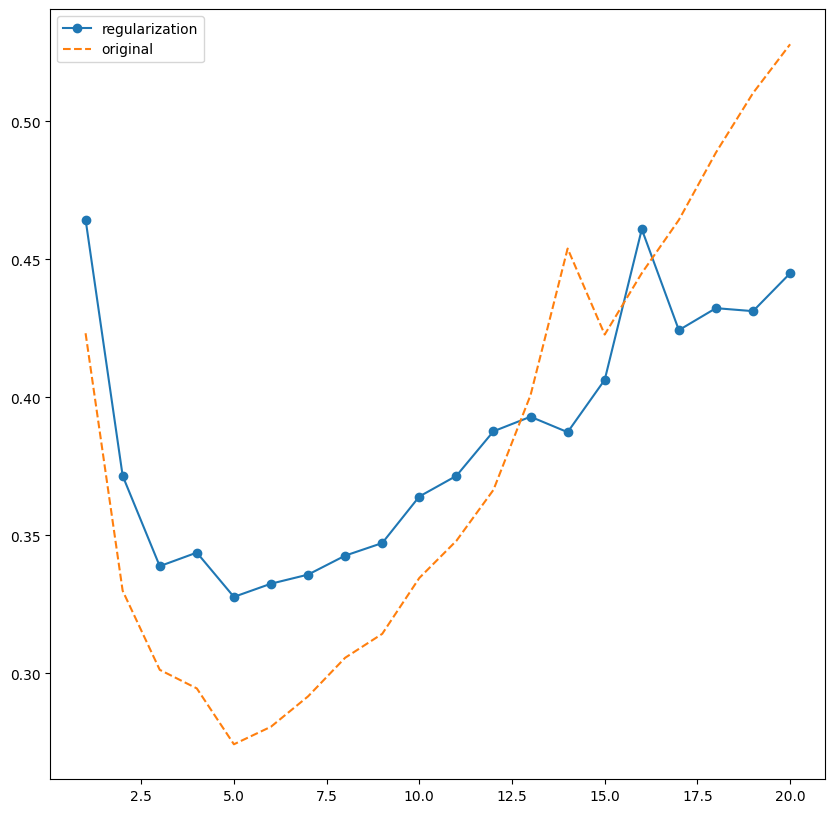

In [31]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values3 = modelb3.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values3, 'o-',label='regularization')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

### Dropout

In [32]:
model4 = models.Sequential()
model4.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(16, activation='relu'))
model4.add(layers.Dropout(0.5)) ## Apagan las neuronas
model4.add(layers.Dense(1, activation='sigmoid'))

In [33]:
model4.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [34]:
modelb4 = model4.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.5969 - loss: 0.6598 - val_accuracy: 0.8225 - val_loss: 0.5837
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7236 - loss: 0.5595 - val_accuracy: 0.8529 - val_loss: 0.4774
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7920 - loss: 0.4747 - val_accuracy: 0.8751 - val_loss: 0.3860
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8369 - loss: 0.4052 - val_accuracy: 0.8818 - val_loss: 0.3295
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8665 - loss: 0.3522 - val_accuracy: 0.8715 - val_loss: 0.3135
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8875 - loss: 0.3053 - val_accuracy: 0.8867 - val_loss: 0.2857
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9071 - loss: 0.2649 - val_accuracy: 0.8885 - val_loss: 0.2801
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9209 - loss: 0.2390 - val_accuracy: 0.8877 - v

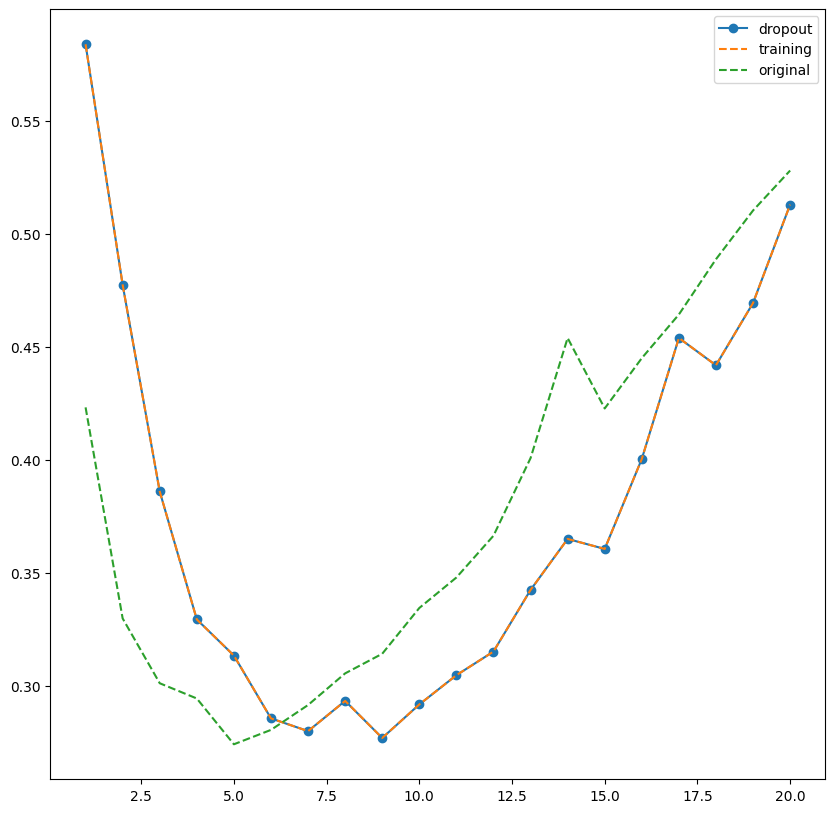

In [36]:
modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values4 = modelb4.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values4, 'o-',label='dropout')
plt.plot(epoch,val_loss_values4, '--',label='training') ## Agregamos
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

## Predicciones

In [37]:
predictions = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [38]:
predictions[10]

array([0.99688345], dtype=float32)

# ACTIVIDAD : aplicar dropout regulador 1 y 2  , aumentar epocas y lograr que entre entrenamiento y validacion deben de ser similar , mas similar  mas nota

In [40]:
from keras.datasets import imdb
from keras import models, layers, regularizers
from keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

In [41]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000,
    index_from=3
)

In [42]:
word_index = imdb.get_word_index()
word_index = dict([(value, key) for (key, value) in word_index.items()])

In [43]:
def vectorizar(sequences, dim=10000):
    results = np.zeros((len(sequences), dim))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1
    return results

In [65]:
x_train = vectorizar(train_data)
x_test = vectorizar(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [45]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [66]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [67]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.7741 - loss: 0.5259 - val_accuracy: 0.8481 - val_loss: 0.4068
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9006 - loss: 0.3160 - val_accuracy: 0.8754 - val_loss: 0.3243
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9217 - loss: 0.2388 - val_accuracy: 0.8847 - val_loss: 0.2900
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9367 - loss: 0.1941 - val_accuracy: 0.8865 - val_loss: 0.2814
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9470 - loss: 0.1638 - val_accuracy: 0.8876 - val_loss: 0.2773
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9549 - loss: 0.1416 - val_accuracy: 0.8837 - val_loss: 0.2928
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9629 - loss: 0.1197 - val_accuracy: 0.8759 - val_loss: 0.3149
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9677 - loss: 0.1060 - val_accuracy: 0.8809 - 

In [ ]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']

epoch = range(1, len(loss_values) + 1)

plt.figure(figsize=(8,6))
plt.plot(epoch, loss_values, 'o-', label='training')
plt.plot(epoch, val_loss_values, '--', label='validation')
plt.legend()
plt.title("Modelo base")
plt.show()

In [ ]:
model2 = models.Sequential()
model2.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
model2.add(layers.Dense(4, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [46]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [68]:
history2 = model2.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9910 - loss: 0.0462 - val_accuracy: 0.8784 - val_loss: 0.3780
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9929 - loss: 0.0417 - val_accuracy: 0.8744 - val_loss: 0.3961
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9946 - loss: 0.0375 - val_accuracy: 0.8769 - val_loss: 0.4136
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9949 - loss: 0.0341 - val_accuracy: 0.8745 - val_loss: 0.4224
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9960 - loss: 0.0294 - val_accuracy: 0.8738 - val_loss: 0.4351
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.9967 - loss: 0.0267 - val_accuracy: 0.8733 - val_loss: 0.4530
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9974 - loss: 0.0232 - val_accuracy: 0.8717 - val_loss: 0.4680
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9976 - loss: 0.0207 - val_accuracy: 0.8723 - v

In [ ]:
model3 = models.Sequential()
model3.add(layers.Dense(16, activation='relu',
                        kernel_regularizer=regularizers.l2(0.001),
                        input_shape=(10000,)))
model3.add(layers.Dense(16, activation='relu',
                        kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history3 = model3.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

In [47]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.7569 - loss: 0.5675 - val_accuracy: 0.8585 - val_loss: 0.4483
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.8828 - loss: 0.3750 - val_accuracy: 0.8767 - val_loss: 0.3479
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9079 - loss: 0.2814 - val_accuracy: 0.8829 - val_loss: 0.3054
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9253 - loss: 0.2272 - val_accuracy: 0.8912 - val_loss: 0.2830
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9377 - loss: 0.1910 - val_accuracy: 0.8875 - val_loss: 0.2813
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9465 - loss: 0.1624 - val_accuracy: 0.8830 - val_loss: 0.2879
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9543 - loss: 0.1409 - val_accuracy: 0.8857 - val_loss: 0.2828
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9607 - loss: 0.1257 - val_accuracy: 0.8831 -

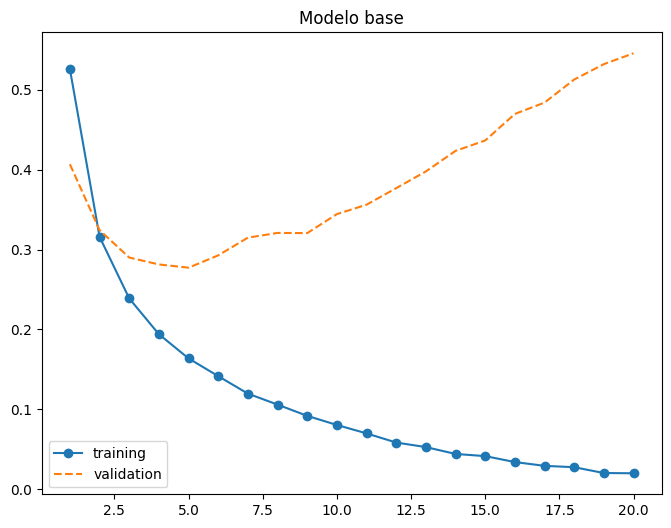

In [69]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']

epoch = range(1, len(loss_values) + 1)

plt.figure(figsize=(8,6))
plt.plot(epoch, loss_values, 'o-', label='training')
plt.plot(epoch, val_loss_values, '--', label='validation')
plt.legend()
plt.title("Modelo base")
plt.show()

In [70]:
model2 = models.Sequential()
model2.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
model2.add(layers.Dense(4, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
history2 = model2.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7551 - loss: 0.5916 - val_accuracy: 0.8305 - val_loss: 0.5037
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8824 - loss: 0.4275 - val_accuracy: 0.8718 - val_loss: 0.4036
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9059 - loss: 0.3380 - val_accuracy: 0.8780 - val_loss: 0.3505
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9181 - loss: 0.2804 - val_accuracy: 0.8886 - val_loss: 0.3136
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.9293 - loss: 0.2393 - val_accuracy: 0.8828 - val_loss: 0.3032
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9377 - loss: 0.2097 - val_accuracy: 0.8924 - val_loss: 0.2823
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9458 - loss: 0.1860 - val_accuracy: 0.8919 - val_loss: 0.2763
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.9519 - loss: 0.1661 - val_accuracy: 0.8885 - 

In [51]:
model3 = models.Sequential()
model3.add(layers.Dense(16, activation='relu',
                        kernel_regularizer=regularizers.l2(0.001),
                        input_shape=(10000,)))
model3.add(layers.Dense(16, activation='relu',
                        kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [52]:
history3 = model3.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.7773 - loss: 0.5675 - val_accuracy: 0.8707 - val_loss: 0.4382
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8941 - loss: 0.3717 - val_accuracy: 0.8881 - val_loss: 0.3593
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9191 - loss: 0.2930 - val_accuracy: 0.8885 - val_loss: 0.3322
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9316 - loss: 0.2538 - val_accuracy: 0.8882 - val_loss: 0.3240
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9435 - loss: 0.2261 - val_accuracy: 0.8650 - val_loss: 0.3798
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9463 - loss: 0.2116 - val_accuracy: 0.8839 - val_loss: 0.3378
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9563 - loss: 0.1942 - val_accuracy: 0.8785 - val_loss: 0.3671
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9613 - loss: 0.1827 - val_accuracy: 0.8829 - 

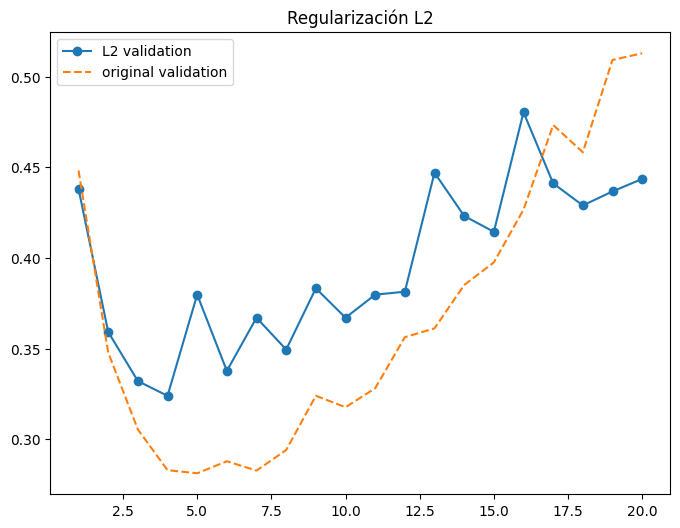

In [53]:
val_loss_values3 = history3.history['val_loss']

epoch = range(1, len(val_loss_values3) + 1)

plt.figure(figsize=(8,6))
plt.plot(epoch, val_loss_values3, 'o-', label='L2 validation')
plt.plot(epoch, val_loss_values, '--', label='original validation')  # del modelo base
plt.legend()
plt.title("Regularización L2")
plt.show()

In [54]:
model4 = models.Sequential()

model4.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model4.add(layers.Dropout(0.5))

model4.add(layers.Dense(16, activation='relu'))
model4.add(layers.Dropout(0.5))

model4.add(layers.Dense(1, activation='sigmoid'))

model4.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [55]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [56]:
history4 = model4.fit(
    partial_x_train,
    partial_y_train,
    epochs=30,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.6161 - loss: 0.6422 - val_accuracy: 0.8291 - val_loss: 0.5175
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7724 - loss: 0.5078 - val_accuracy: 0.8637 - val_loss: 0.3987
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8256 - loss: 0.4287 - val_accuracy: 0.8624 - val_loss: 0.3567
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8613 - loss: 0.3674 - val_accuracy: 0.8719 - val_loss: 0.3193
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8841 - loss: 0.3208 - val_accuracy: 0.8865 - val_loss: 0.2883
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9022 - loss: 0.2814 - val_accuracy: 0.8869 - val_loss: 0.2855
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9175 - loss: 0.2497 - val_accuracy: 0.8864 - val_loss: 0.2891
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9276 - loss: 0.2187 - val_accuracy: 0.8871 - v

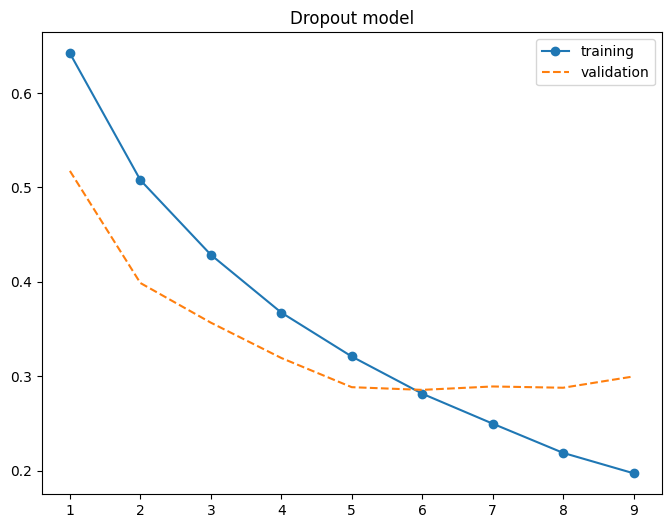

In [57]:
loss_values4 = history4.history['loss']
val_loss_values4 = history4.history['val_loss']

epoch = range(1, len(loss_values4) + 1)

plt.figure(figsize=(8,6))

plt.plot(epoch, loss_values4, 'o-', label='training')  # ✔ correcto
plt.plot(epoch, val_loss_values4, '--', label='validation')  # ✔ correcto

plt.legend()
plt.title("Dropout model")
plt.show()


In [58]:
predictions = model4.predict(x_test)
print(predictions[10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[0.8593528]
